# 06 - Salary Regression Model
**Goal:** Predict annual salary from respondent characteristics, and judge the model honestly against simple baselines.
Key rules: split before any statistic is computed, keep leaking columns out, impute inside the pipeline, and model the log of salary.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             median_absolute_error, r2_score)
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 13})
PRIMARY = "#4C72B0"
ACCENT = "#C44E52"

RANDOM_STATE = 42
TARGET = "ConvertedCompYearly"

DATA_PATH = Path("../data/processed/clean_salaries.csv")
FIGURES_DIR = Path("../reports/figures")
REPORTS_DIR = Path("../reports")
MODELS_DIR = Path("../models")
for folder in (FIGURES_DIR, MODELS_DIR):
    folder.mkdir(parents=True, exist_ok=True)
assert DATA_PATH.exists(), f"File not found: {DATA_PATH.resolve()}"

def save_fig(fig, name):
    """Save a figure to reports/figures with a consistent resolution."""
    path = FIGURES_DIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved: {path}")

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded shape: {df.shape}")

Loaded shape: (21702, 14)


In [2]:
# For respondents paid in USD, the original salary IS the target.
# A model that sees CompTotal would just copy it, so it would look perfect and be useless.
usd_rows = df[df["CurrencyCode"] == "USD"]
print("Correlation between CompTotal and the target for USD respondents:")
print(usd_rows[["CompTotal", TARGET]].corr().round(3))

LEAKING_COLUMNS = ["CompTotal", "Currency", "CurrencyCode"]
print("\nExcluded from the model:", LEAKING_COLUMNS)

Correlation between CompTotal and the target for USD respondents:
                     CompTotal  ConvertedCompYearly
CompTotal                  1.0                  1.0
ConvertedCompYearly        1.0                  1.0

Excluded from the model: ['CompTotal', 'Currency', 'CurrencyCode']


In [3]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)

# Model the log of salary: salaries are multiplicative and right-skewed
y_train = np.log(df_train[TARGET])
y_test = np.log(df_test[TARGET])

print(f"Train: {len(df_train):,} rows | Test: {len(df_test):,} rows")
print(f"Median salary  train: ${df_train[TARGET].median():,.0f}  |  test: ${df_test[TARGET].median():,.0f}")

Train: 17,361 rows | Test: 4,341 rows
Median salary  train: $81,210  |  test: $80,254


In [4]:
def simplify_education(text):
    """Map the long survey answers to a few readable groups."""
    if pd.isna(text):
        return np.nan
    t = text.lower()
    if "professional degree" in t or "ph.d" in t or "doctorate" in t:
        return "Doctorate / professional"
    if "master" in t:
        return "Master's"
    if "bachelor" in t:
        return "Bachelor's"
    if "associate" in t:
        return "Associate"
    if "some college" in t:
        return "Some college"
    if "secondary" in t:
        return "Secondary school"
    if "primary" in t:
        return "Primary school"
    return "Other"

def clean_name(lang):
    """Make a safe column name (C++ and C# must not collide with C)."""
    return re.sub(r"\W+", "_", lang.replace("+", "plus").replace("#", "sharp")).strip("_")

NUM_COLS = ["WorkExp"]
CAT_COLS = ["Country", "DevType", "EdGroup", "RemoteWork", "OrgSize", "Age", "Employment"]

def build_features(frame, language_list):
    """Turn raw survey rows into model features. Uses no statistic computed from the data."""
    X = pd.DataFrame(index=frame.index)
    X["WorkExp"] = pd.to_numeric(frame["WorkExp"], errors="coerce")
    X["Country"] = frame["Country"]
    X["DevType"] = frame["DevType"]
    X["EdGroup"] = frame["EdLevel"].apply(simplify_education)
    X["RemoteWork"] = frame["RemoteWork"]
    X["OrgSize"] = frame["OrgSize"]
    X["Age"] = frame["Age"]
    X["Employment"] = frame["Employment"]

    # Missing categories become their own level (a constant, so no leakage)
    for col in CAT_COLS:
        X[col] = X[col].fillna("Missing").astype(object)

    # Multi-select languages become one 0/1 flag per language
    lang_sets = frame["LanguageHaveWorkedWith"].apply(
        lambda s: {x.strip() for x in s.split(";")} if isinstance(s, str) else set()
    )
    for lang in language_list:
        X[f"Lang_{clean_name(lang)}"] = lang_sets.apply(lambda s, l=lang: int(l in s))
    return X

# The 15 most used languages, chosen from the TRAIN set only (salary is not involved)
lang_counts = (
    df_train["LanguageHaveWorkedWith"].dropna()
            .str.split(";").explode().str.strip()
            .value_counts()
)
TOP_LANGS = lang_counts.head(15).index.tolist()
print("Languages used as features:", TOP_LANGS)

X_train = build_features(df_train, TOP_LANGS)
X_test = build_features(df_test, TOP_LANGS)
LANG_COLS = [c for c in X_train.columns if c.startswith("Lang_")]

print(f"\nFeature matrix: {X_train.shape[1]} columns")
X_train.head(3)

Languages used as features: ['JavaScript', 'HTML/CSS', 'SQL', 'Python', 'Bash/Shell (all shells)', 'TypeScript', 'C#', 'Java', 'PowerShell', 'C++', 'PHP', 'C', 'Go', 'Rust', 'Kotlin']

Feature matrix: 23 columns


,WorkExp,Country,DevType,EdGroup,RemoteWork,OrgSize,Age,Employment,Lang_JavaScript,Lang_HTML_CSS,...,Lang_TypeScript,Lang_Csharp,Lang_Java,Lang_PowerShell,Lang_Cplusplus,Lang_PHP,Lang_C,Lang_Go,Lang_Rust,Lang_Kotlin
13387,20.0,New Zealand,"Developer, front-end",Some college,"Hybrid (some in-person, leans heavy to flexibi...","5,000 to 9,999 employees",35-44 years old,Employed,1,1,...,1,0,1,0,0,1,0,0,0,0
601,8.0,Chile,"Developer, front-end",Associate,"Hybrid (some in-person, leans heavy to flexibi...","10,000 or more employees",35-44 years old,Employed,1,1,...,1,0,0,0,0,0,0,1,0,0
8354,2.0,United States,Data engineer,Bachelor's,In-person,20 to 99 employees,25-34 years old,Employed,1,0,...,0,1,1,0,0,0,0,0,0,0


In [5]:
def make_preprocessor():
    """Imputation, scaling and encoding. Fitted on training data only, inside the pipeline."""
    return ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),   # median learned from train only
            ("scale", StandardScaler()),
        ]), NUM_COLS),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist",
                              min_frequency=30, sparse_output=False), CAT_COLS),
        ("lang", "passthrough", LANG_COLS),
    ])

ridge = Pipeline([
    ("prep", make_preprocessor()),
    ("model", RidgeCV(alphas=np.logspace(-2, 3, 20))),
])

hgb = Pipeline([
    ("prep", make_preprocessor()),
    ("model", HistGradientBoostingRegressor(
        max_iter=500, learning_rate=0.05, max_leaf_nodes=15, min_samples_leaf=40,
        l2_regularization=1.0, early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=20, random_state=RANDOM_STATE)),
])
print("Pipelines ready.")

Pipelines ready.


In [6]:
def evaluate(name, y_true_log, y_pred_log):
    """Metrics on the log scale and in dollars."""
    actual = np.exp(y_true_log)
    predicted = np.exp(y_pred_log)
    return {
        "model": name,
        "RMSE (log)": np.sqrt(mean_squared_error(y_true_log, y_pred_log)),
        "R2 (log)": r2_score(y_true_log, y_pred_log),
        "MAE ($)": mean_absolute_error(actual, predicted),
        "Median abs error ($)": median_absolute_error(actual, predicted),
        "Within 25%": np.mean(np.abs(predicted / actual - 1) <= 0.25),
    }

results = []

# Baseline 1: always predict the global median salary of the training set
results.append(evaluate("Global median", y_test, np.full(len(y_test), y_train.median())))

# Baseline 2: predict the median salary of the respondent's country (learned from train)
country_median = y_train.groupby(df_train["Country"]).median()
pred_country = df_test["Country"].map(country_median).fillna(y_train.median()).to_numpy()
results.append(evaluate("Country median", y_test, pred_country))

pd.DataFrame(results).round(3)

,model,RMSE (log),R2 (log),MAE ($),Median abs error ($),Within 25%
0,Global median,1.013,-0.035,52271.894,37521.000,0.291
1,Country median,0.741,0.447,37867.755,23912.746,0.396


In [7]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, pipe in {"Ridge regression": ridge, "Gradient boosting": hgb}.items():
    cv_rmse = -cross_val_score(pipe, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error")
    print(f"{name}: cross-validated RMSE (log) = {cv_rmse.mean():.3f} +/- {cv_rmse.std():.3f}")

    pipe.fit(X_train, y_train)
    results.append(evaluate(name, y_test, pipe.predict(X_test)))

print(f"\nRidge alpha chosen: {ridge.named_steps['model'].alpha_:.3f}")

metrics = pd.DataFrame(results)
metrics.round(4).to_csv(REPORTS_DIR / "model_metrics.csv", index=False)
display(metrics.round(3))

Ridge regression: cross-validated RMSE (log) = 0.647 +/- 0.008
Gradient boosting: cross-validated RMSE (log) = 0.651 +/- 0.010

Ridge alpha chosen: 2.336


,model,RMSE (log),R2 (log),MAE ($),Median abs error ($),Within 25%
0,Global median,1.013,-0.035,52271.894,37521.000,0.291
1,Country median,0.741,0.447,37867.755,23912.746,0.396
2,Ridge regression,0.642,0.585,33080.622,19507.751,0.443
3,Gradient boosting,0.641,0.586,31736.581,18864.090,0.471


Saved: ..\reports\figures\08_model_comparison.png


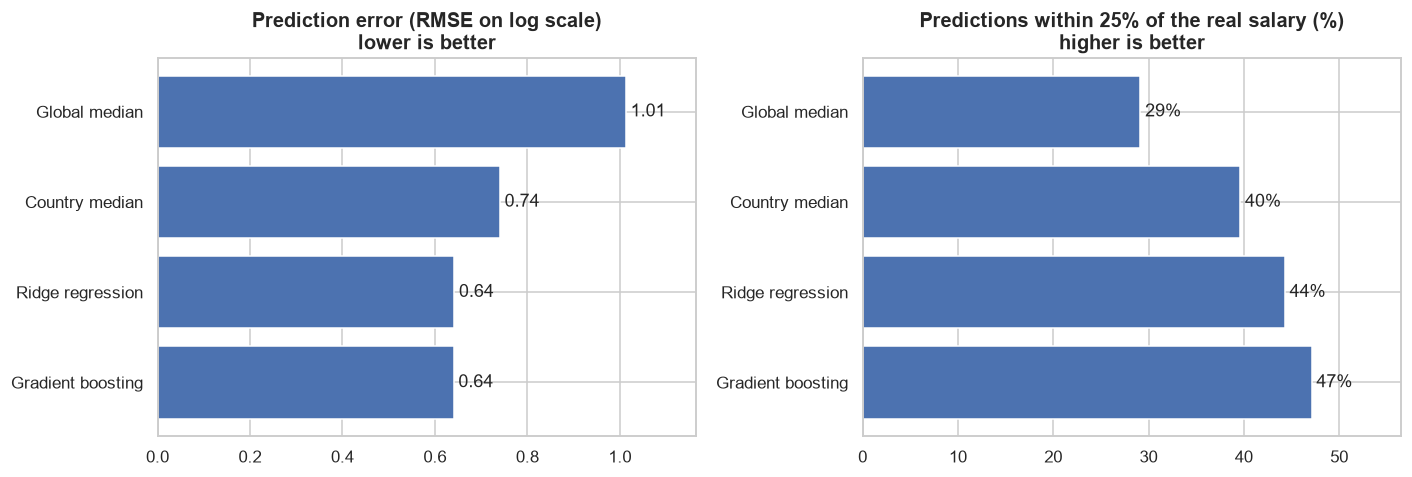

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
names = metrics["model"].tolist()

axes[0].barh(names, metrics["RMSE (log)"], color=PRIMARY)
axes[0].invert_yaxis()
axes[0].set_title("Prediction error (RMSE on log scale)\nlower is better")
for i, v in enumerate(metrics["RMSE (log)"]):
    axes[0].text(v + 0.01, i, f"{v:.2f}", va="center")
axes[0].set_xlim(0, metrics["RMSE (log)"].max() * 1.15)

axes[1].barh(names, metrics["Within 25%"] * 100, color=PRIMARY)
axes[1].invert_yaxis()
axes[1].set_title("Predictions within 25% of the real salary (%)\nhigher is better")
for i, v in enumerate(metrics["Within 25%"] * 100):
    axes[1].text(v + 0.5, i, f"{v:.0f}%", va="center")
axes[1].set_xlim(0, (metrics["Within 25%"] * 100).max() * 1.2)

plt.tight_layout()
save_fig(fig, "08_model_comparison.png")
plt.show()

Saved: ..\reports\figures\09_predicted_vs_actual.png


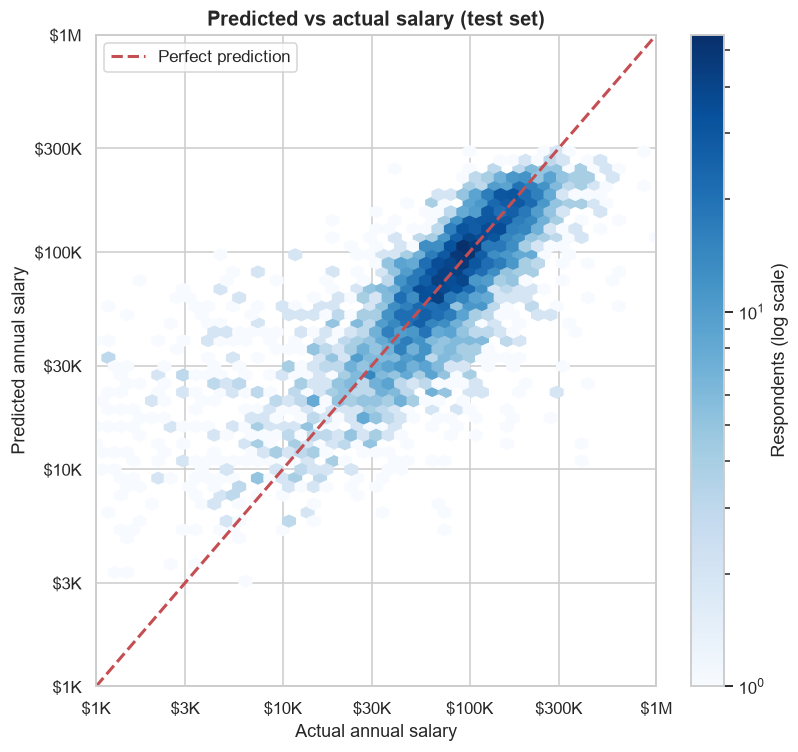

In [9]:
pred_best = hgb.predict(X_test)

ticks = np.log10([1e3, 3e3, 1e4, 3e4, 1e5, 3e5, 1e6])
tick_labels = ["$1K", "$3K", "$10K", "$30K", "$100K", "$300K", "$1M"]

fig, ax = plt.subplots(figsize=(7.5, 7))
hb = ax.hexbin(y_test / np.log(10), pred_best / np.log(10),
               gridsize=45, bins="log", cmap="Blues", mincnt=1)
ax.plot([3, 6], [3, 6], linestyle="--", color=ACCENT, linewidth=2, label="Perfect prediction")
ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels)
ax.set_yticks(ticks)
ax.set_yticklabels(tick_labels)
ax.set_xlim(3, 6)
ax.set_ylim(3, 6)
ax.set_title("Predicted vs actual salary (test set)")
ax.set_xlabel("Actual annual salary")
ax.set_ylabel("Predicted annual salary")
fig.colorbar(hb, ax=ax, label="Respondents (log scale)")
ax.legend(loc="upper left")
plt.tight_layout()
save_fig(fig, "09_predicted_vs_actual.png")
plt.show()

In [10]:
predicted = np.exp(pred_best)
actual = df_test[TARGET].to_numpy()

errors = pd.DataFrame({
    "Country": df_test["Country"].to_numpy(),
    "abs_pct_error": np.abs(predicted / actual - 1),
})

by_country = (
    errors.groupby("Country")["abs_pct_error"]
          .agg(n="size", median_abs_pct_error="median")
          .query("n >= 100")
          .sort_values("median_abs_pct_error")
)
print("Median absolute percentage error by country (n >= 100 in the test set):")
display(by_country.round(3))

Median absolute percentage error by country (n >= 100 in the test set):


,n,median_abs_pct_error
Country,,
Germany,382,0.187
Australia,103,0.206
Netherlands,133,0.220
United States,956,0.222
Canada,177,0.226
France,188,0.226
Italy,116,0.232
Spain,121,0.244
United Kingdom,269,0.272


,feature,error_increase,std
0,Country,0.3882,0.0077
1,Years of experience,0.0955,0.0027
6,Age,0.0292,0.0016
5,Company size,0.0245,0.0019
8,Languages (15 flags together),0.0197,0.0012
2,Job role,0.0154,0.0022
4,Work arrangement,0.0135,0.0006
3,Education,0.0051,0.0006
7,Employment type,0.0014,0.0004


Saved: ..\reports\figures\10_feature_importance.png


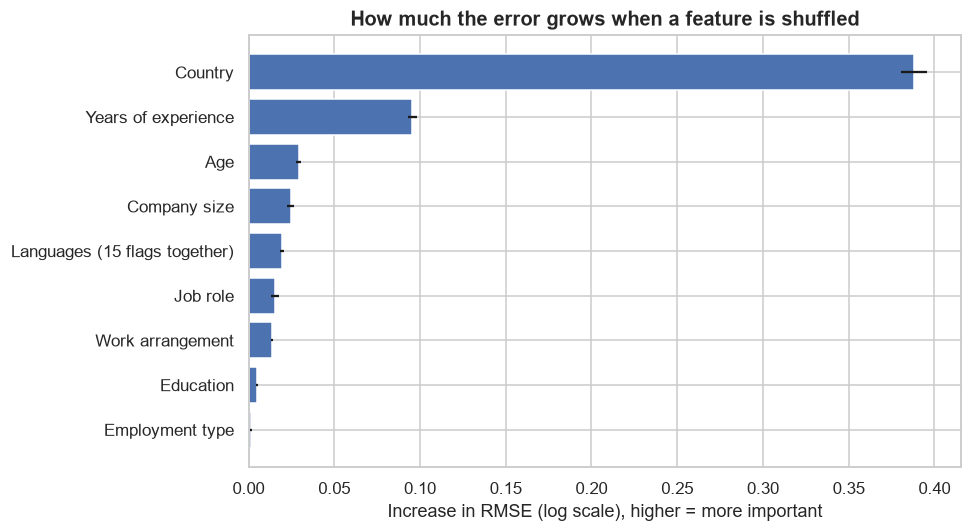

In [11]:
def rmse_log(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def grouped_permutation_importance(model, X, y, groups, n_repeats=5, seed=RANDOM_STATE):
    """Shuffle each feature group on the test set and measure how much the error grows."""
    rng = np.random.default_rng(seed)
    base_error = rmse_log(y, model.predict(X))
    rows = []
    for name, cols in groups.items():
        increases = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            idx = rng.permutation(len(X))
            X_perm[cols] = X[cols].iloc[idx].to_numpy()   # shuffle the whole group together
            increases.append(rmse_log(y, model.predict(X_perm)) - base_error)
        rows.append({"feature": name, "error_increase": np.mean(increases), "std": np.std(increases)})
    return pd.DataFrame(rows).sort_values("error_increase")

groups = {
    "Country": ["Country"],
    "Years of experience": ["WorkExp"],
    "Job role": ["DevType"],
    "Education": ["EdGroup"],
    "Work arrangement": ["RemoteWork"],
    "Company size": ["OrgSize"],
    "Age": ["Age"],
    "Employment type": ["Employment"],
    "Languages (15 flags together)": LANG_COLS,
}

importance = grouped_permutation_importance(hgb, X_test, y_test, groups)
display(importance.sort_values("error_increase", ascending=False).round(4))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importance["feature"], importance["error_increase"], xerr=importance["std"], color=PRIMARY)
ax.set_title("How much the error grows when a feature is shuffled")
ax.set_xlabel("Increase in RMSE (log scale), higher = more important")
ax.set_ylabel("")
plt.tight_layout()
save_fig(fig, "10_feature_importance.png")
plt.show()

In [12]:
# Start from a real test row so every column is valid, then override the profile.
# OrgSize, Age and Employment are carried over from that row.
base = df_test.iloc[[0]].copy()
base["WorkExp"] = 8
base["DevType"] = "Developer, back-end"
base["EdLevel"] = "Bachelor's degree"
base["RemoteWork"] = "Remote"
base["LanguageHaveWorkedWith"] = "Python;SQL;JavaScript"

rows = []
for country in ["United States", "Germany", "United Kingdom", "Poland", "Brazil", "India"]:
    row = base.copy()
    row["Country"] = country
    pred = float(np.exp(hgb.predict(build_features(row, TOP_LANGS))[0]))
    rows.append({"Country": country, "Predicted salary (USD)": round(pred, -2)})

print("Same profile (8 years, back-end, remote, Python/SQL/JavaScript), different country:")
display(pd.DataFrame(rows))

Same profile (8 years, back-end, remote, Python/SQL/JavaScript), different country:


,Country,Predicted salary (USD)
0,United States,145500.0
1,Germany,103500.0
2,United Kingdom,124400.0
3,Poland,74200.0
4,Brazil,39400.0
5,India,33900.0


In [13]:
artifact = {
    "pipeline": hgb,
    "top_languages": TOP_LANGS,
    "target": "natural log of ConvertedCompYearly (predict, then apply np.exp)",
}
joblib.dump(artifact, MODELS_DIR / "salary_model.joblib")
print(f"Saved: {(MODELS_DIR / 'salary_model.joblib').resolve()}")

Saved: D:\tech-salary-analysis\models\salary_model.joblib


In [14]:
focus = ["Germany", "United States", "Netherlands", "United Kingdom",
         "Poland", "Brazil", "India", "Ukraine"]

def log_iqr(s):
    """Spread of the middle 50% of salaries, on the log scale."""
    q = np.log(s).quantile([0.25, 0.75])
    return q.iloc[1] - q.iloc[0]

dispersion = (
    df[df["Country"].isin(focus)]
      .groupby("Country")
      .agg(n=(TARGET, "size"),
           log_iqr=(TARGET, log_iqr),
           share_paid_in_usd=("CurrencyCode", lambda s: (s == "USD").mean()))
      .loc[focus]
)
display(dispersion.round(2))

,n,log_iqr,share_paid_in_usd
Country,,,
Germany,1906,0.44,0.00
United States,4818,0.60,1.00
Netherlands,575,0.56,0.00
United Kingdom,1402,0.68,0.00
Poland,552,0.93,0.05
Brazil,577,1.27,0.07
India,983,1.61,0.02
Ukraine,608,1.98,0.37


In [15]:
from sklearn.model_selection import cross_val_predict

# Out-of-fold residuals on the TRAIN set only (the test set stays untouched)
oof_pred = cross_val_predict(hgb, X_train, y_train, cv=cv)
oof_resid = y_train - oof_pred
low_q, high_q = oof_resid.quantile([0.10, 0.90])
print(f"80% range of the error on the log scale: {low_q:.2f} to {high_q:.2f}")

# Check on the test set: this should be close to 80%
test_resid = y_test - hgb.predict(X_test)
coverage = ((test_resid >= low_q) & (test_resid <= high_q)).mean()
print(f"Share of test salaries inside the range: {coverage:.1%}")

# Same what-if as before, now with a range
rows = []
for country in ["United States", "Germany", "United Kingdom", "Poland", "Brazil", "India"]:
    row = base.copy()
    row["Country"] = country
    pred_log = hgb.predict(build_features(row, TOP_LANGS))[0]
    rows.append({
        "Country": country,
        "Prediction": round(float(np.exp(pred_log)), -2),
        "Range low (10th pct)": round(float(np.exp(pred_log + low_q)), -2),
        "Range high (90th pct)": round(float(np.exp(pred_log + high_q)), -2),
    })
display(pd.DataFrame(rows))

# Save the model again, now including the range
artifact["residual_quantiles_log"] = {"p10": float(low_q), "p90": float(high_q)}
joblib.dump(artifact, MODELS_DIR / "salary_model.joblib")

80% range of the error on the log scale: -0.58 to 0.66
Share of test salaries inside the range: 80.6%


,Country,Prediction,Range low (10th pct),Range high (90th pct)
0,United States,145500.0,81200.0,280900.0
1,Germany,103500.0,57700.0,199800.0
2,United Kingdom,124400.0,69400.0,240200.0
3,Poland,74200.0,41400.0,143300.0
4,Brazil,39400.0,22000.0,76000.0
5,India,33900.0,18900.0,65400.0


['..\\models\\salary_model.joblib']

In [16]:
# Does the 80% range cover about 80% of salaries in every country?
test_cov = pd.DataFrame({
    "Country": df_test["Country"].to_numpy(),
    "inside": ((test_resid >= low_q) & (test_resid <= high_q)).to_numpy(),
})

coverage_by_country = (
    test_cov.groupby("Country")["inside"]
            .agg(n="size", coverage="mean")
            .query("n >= 100")
            .sort_values("coverage")
)
display(coverage_by_country.round(3))

,n,coverage
Country,,
Ukraine,140,0.414
India,163,0.589
Brazil,127,0.606
Poland,112,0.777
Spain,121,0.851
France,188,0.883
United Kingdom,269,0.885
United States,956,0.891
Canada,177,0.893


In [17]:
# Prediction ranges: one per larger country, plus one shared range for all smaller countries.
# All ranges come from out-of-fold residuals on the TRAIN set only.
MIN_TRAIN_FOR_OWN_RANGE = 150

train_resid = pd.DataFrame({
    "Country": df_train["Country"].to_numpy(),
    "resid": oof_resid.to_numpy(),
})
counts = train_resid["Country"].value_counts()
own_countries = counts[counts >= MIN_TRAIN_FOR_OWN_RANGE].index

# Own range for each larger country
country_q = (
    train_resid[train_resid["Country"].isin(own_countries)]
      .groupby("Country")["resid"]
      .quantile([0.10, 0.90])
      .unstack()
      .rename(columns={0.10: "p10", 0.90: "p90"})
)

# One shared range for the smaller countries, computed from THEIR residuals only
small_resid = train_resid[~train_resid["Country"].isin(own_countries)]["resid"]
other_p10, other_p90 = small_resid.quantile([0.10, 0.90])

print(f"Countries with their own range: {len(country_q)}")
print(f"Residuals behind the shared range (smaller countries): {len(small_resid):,}")
print(f"Shared range for smaller countries (log scale): {other_p10:.2f} to {other_p90:.2f}")
print(f"For comparison, the global range was: {low_q:.2f} to {high_q:.2f}")

def get_range(country):
    """Return (p10, p90) for a country: its own range, or the shared one for smaller countries."""
    if country in country_q.index:
        return country_q.loc[country, "p10"], country_q.loc[country, "p90"]
    return other_p10, other_p90

# Check on the test set, which was not used to compute any of these ranges
bounds = np.array([get_range(c) for c in df_test["Country"]])
resid = test_resid.to_numpy()
inside = (resid >= bounds[:, 0]) & (resid <= bounds[:, 1])
print(f"\nOverall coverage: {inside.mean():.1%}")

# Coverage for larger vs smaller countries
group = np.where(df_test["Country"].isin(country_q.index), "Larger countries (own range)",
                 "Smaller countries (shared range)")
group_cov = (
    pd.DataFrame({"group": group, "inside": inside})
      .groupby("group")["inside"]
      .agg(rows="size", coverage="mean")
)
print("\nCoverage by group:")
display(group_cov.round(3))

# Coverage by country (target: about 80%)
cov = (
    pd.DataFrame({"Country": df_test["Country"].to_numpy(), "inside": inside})
      .groupby("Country")["inside"]
      .agg(n="size", coverage="mean")
      .query("n >= 100")
      .sort_values("coverage")
)
print("\nCoverage by country (n >= 100 in the test set):")
display(cov.round(3))

# Same what-if as before, with the range of each country
rows = []
for country in ["United States", "Germany", "United Kingdom", "Poland", "Brazil", "India"]:
    row = base.copy()
    row["Country"] = country
    pred_log = hgb.predict(build_features(row, TOP_LANGS))[0]
    p10, p90 = get_range(country)
    rows.append({
        "Country": country,
        "Prediction": round(float(np.exp(pred_log)), -2),
        "Range low (10th pct)": round(float(np.exp(pred_log + p10)), -2),
        "Range high (90th pct)": round(float(np.exp(pred_log + p90)), -2),
    })
display(pd.DataFrame(rows))

# Save the model together with all ranges
artifact["residual_quantiles_log"] = {
    "global": {"p10": float(low_q), "p90": float(high_q)},
    "by_country": country_q.to_dict(orient="index"),
    "smaller_countries": {"p10": float(other_p10), "p90": float(other_p90)},
}
joblib.dump(artifact, MODELS_DIR / "salary_model.joblib")
print("\nModel saved with country-specific ranges.")

Countries with their own range: 21
Residuals behind the shared range (smaller countries): 3,753
Shared range for smaller countries (log scale): -1.22 to 0.87
For comparison, the global range was: -0.58 to 0.66

Overall coverage: 80.4%

Coverage by group:


,rows,coverage
group,,
Larger countries (own range),3429,0.803
Smaller countries (shared range),912,0.806



Coverage by country (n >= 100 in the test set):


,n,coverage
Country,,
United Kingdom,269,0.770
Netherlands,133,0.782
Spain,121,0.785
India,163,0.785
Poland,112,0.786
France,188,0.787
Brazil,127,0.795
Australia,103,0.796
United States,956,0.815


,Country,Prediction,Range low (10th pct),Range high (90th pct)
0,United States,145500.0,92400.0,240100.0
1,Germany,103500.0,72300.0,154300.0
2,United Kingdom,124400.0,79400.0,206800.0
3,Poland,74200.0,38400.0,146300.0
4,Brazil,39400.0,16500.0,100500.0
5,India,33900.0,13100.0,89900.0



Model saved with country-specific ranges.


In [19]:
# The reusable module must produce exactly the same features as the code in this notebook
import sys
import importlib

sys.path.append(str(Path("..").resolve()))   # make the repository root importable
import src.features as src_features
importlib.reload(src_features)                # pick up edits made after the first import
build_features_src = src_features.build_features

pd.testing.assert_frame_equal(build_features(base, TOP_LANGS), build_features_src(base, TOP_LANGS))
pd.testing.assert_frame_equal(X_test.iloc[:200], build_features_src(df_test.iloc[:200], TOP_LANGS))
print("src.features matches the notebook code.")

# Print the terminal command that reproduces the notebook's United States example
b = base.iloc[0]
cmd = (
    'python -m src.predict --country "United States" --experience 8 '
    '--role "' + str(b["DevType"]) + '" '
    "--education \"Bachelor's degree\" "
    '--remote "' + str(b["RemoteWork"]) + '" '
    '--org-size "' + str(b["OrgSize"]) + '" '
    '--age "' + str(b["Age"]) + '" '
    '--employment "' + str(b["Employment"]) + '" '
    '--languages "Python;SQL;JavaScript"'
)
print("\nRun this in the terminal (repository root):")
print(cmd)

src.features matches the notebook code.

Run this in the terminal (repository root):
python -m src.predict --country "United States" --experience 8 --role "Developer, back-end" --education "Bachelor's degree" --remote "Remote" --org-size "nan" --age "25-34 years old" --employment "Independent contractor, freelancer, or self-employed" --languages "Python;SQL;JavaScript"
